Cargar dataset

In [26]:
import keras
from tensorflow.keras.preprocessing.image import (
    DirectoryIterator, ImageDataGenerator
)
# Solo usamos estas clases por ahora
used_classes = ['tiger', 'dog', 'zero']

gen = ImageDataGenerator(
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

train_dataset = gen.flow_from_directory(
    'dataset/train',
    target_size=(150, 150),
    batch_size=10,
    classes=used_classes,
    class_mode='categorical',
    subset='training',
)

validation_dataset = gen.flow_from_directory(
    'dataset/train',
    target_size=(150, 150),
    batch_size=10,
    classes=used_classes,
    class_mode='categorical',
    subset='validation',
)

Found 505 images belonging to 3 classes.
Found 124 images belonging to 3 classes.


In [27]:
# Inception necesita que los pixeles esten entre -1 y 1, esto se consigue con la reescale layer
scale_layer = keras.layers.Rescaling(1./127.5, offset=-1)

# Modelo base de inception v3
base_model = keras.applications.InceptionV3(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)

# NO entrenamos la base
base_model.trainable = False

inputs = keras.Input(shape=(150, 150, 3))

model = keras.Sequential([
    inputs,
    scale_layer,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.2), # Regularizacion
    keras.layers.Dense(len(used_classes), activation='softmax') # esta capa clasifica las clases
])

model.summary(
    show_trainable=True
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ rescaling_3 (Rescaling)     │ (None, 150, 150, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ inception_v3 (Functional)   │ (None, 3, 3, 2048)    │ 21,802,784 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_3  │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 3)             │      6,147 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 21,808,931 (83.19 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

Entrenamos

In [ ]:
epochs = 20
init_learning_rate = 1e-1

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=init_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Metemos callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'inception_model.weights.h5',
    save_best_only=True,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max'
)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=5,
    monitor='val_accuracy',
    mode='max',
    restore_best_weights=True
)
reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    factor=0.1,
    patience=3,
    monitor='val_accuracy',
    mode='max',
    min_lr=1e-6
)

# Entrenamos el modelo
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb]
)

/home/don-berge/Documentos/IIA-TPS/TP-FINAL/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 581ms/step - accuracy: 0.6777 - loss: 28.7574 - val_accuracy: 0.9758 - val_loss: 0.8552 - learning_rate: 0.1000
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 26s 506ms/step - accuracy: 0.9183 - loss: 5.8236 - val_accuracy: 0.9597 - val_loss: 3.9321 - learning_rate: 0.1000
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 471ms/step - accuracy: 0.9208 - loss: 5.9739 - val_accuracy: 0.9758 - val_loss: 1.5568 - learning_rate: 0.1000
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 485ms/step - accuracy: 0.9450 - loss: 4.3943 - val_accuracy: 0.9919 - val_loss: 1.2168 - learning_rate: 0.1000
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 469ms/step - accuracy: 0.9602 - loss: 2.5950 - val_accuracy: 0.9919 - val_loss: 0.2173 - learning_rate: 0.1000
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 472ms/step - accuracy: 0.9725 - loss: 3.7533 - val_accuracy: 0.9839 - val_loss: 1.6137 - learning_rate: 0.1000
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 468ms/step - accuracy: 0.9347 - loss: 4

Graficamos las curvas de entrenamiento

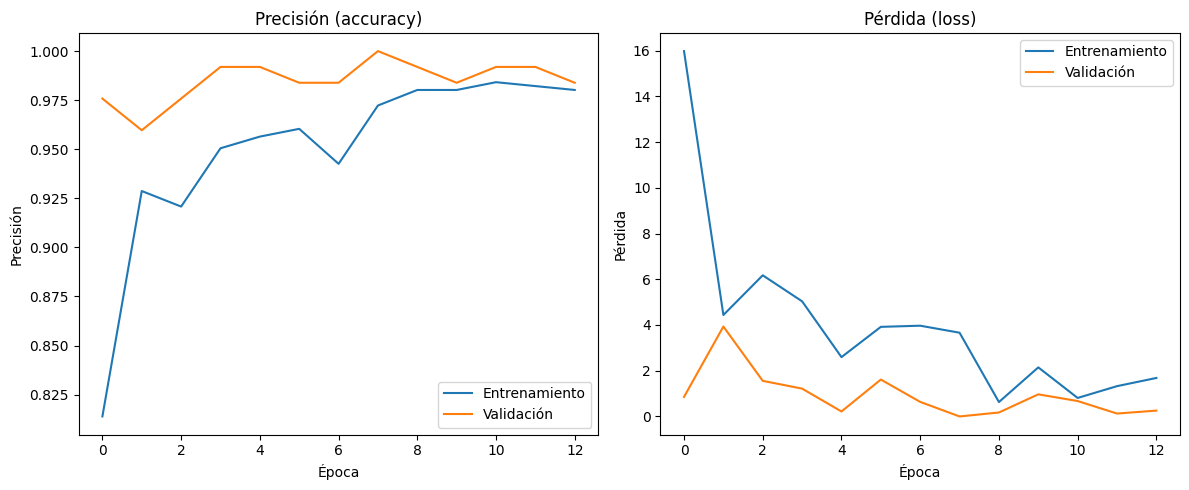

In [29]:
import matplotlib.pyplot as plt

# Graficar accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión (accuracy)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Graficar loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

Evaluamos sobre el conjunto de train, validacion y test

Found 20 images belonging to 3 classes.
51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 369ms/step - accuracy: 0.9837 - loss: 1.1769
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 376ms/step - accuracy: 0.9976 - loss: 0.0458


/home/don-berge/Documentos/IIA-TPS/TP-FINAL/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.7333 - loss: 63.5751


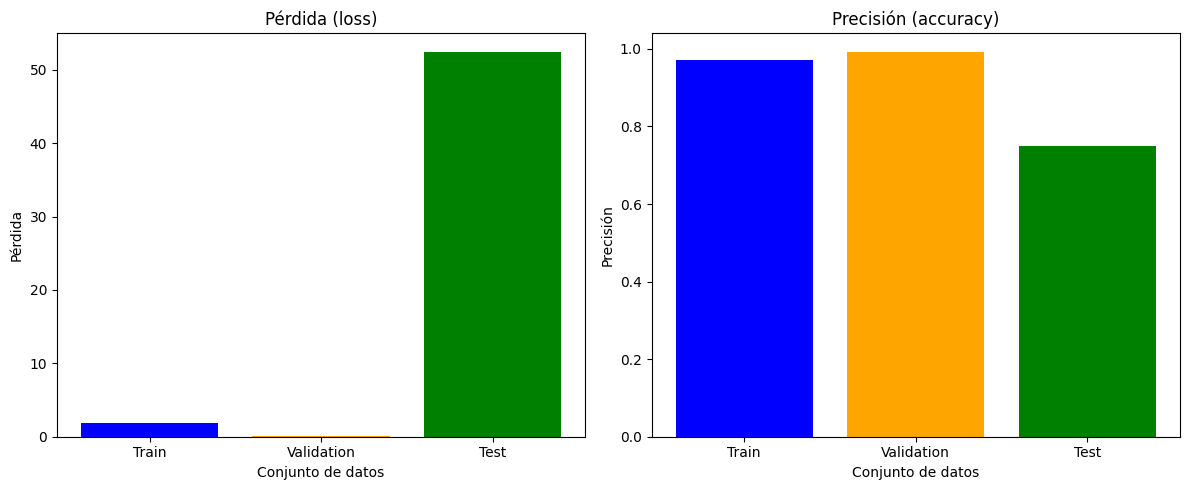

In [32]:
test_dataset = ImageDataGenerator()

test_dataset = test_dataset.flow_from_directory(
    'dataset/test',
    target_size=(150, 150),
    batch_size=10,
    classes=used_classes,
    class_mode='categorical',
)

# Evaluamos el modelo
train_loss, train_accuracy = model.evaluate(train_dataset)
validation_loss, validation_accuracy = model.evaluate(validation_dataset)
test_loss, test_accuracy = model.evaluate(test_dataset)

# Graficar el loss y accuracy de train, validacion y test
# en un histograma, donde cada columna tiene un color diferente
labels = ['Train', 'Validation', 'Test']
losses = [train_loss, validation_loss, test_loss]
accuracies = [train_accuracy, validation_accuracy, test_accuracy]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(labels, losses, color=['blue', 'orange', 'green'])
plt.title('Pérdida (loss)')
plt.xlabel('Conjunto de datos')
plt.ylabel('Pérdida')
plt.subplot(1, 2, 2)
plt.bar(labels, accuracies, color=['blue', 'orange', 'green'])
plt.title('Precisión (accuracy)')
plt.xlabel('Conjunto de datos')
plt.ylabel('Precisión')
plt.tight_layout()
plt.show()


Ahora hacemos fine tunning

In [38]:
# Ahora hacemos fine tunning
base_model_layers = len(base_model.layers)

print(f"Base model has {base_model_layers} layers.")

fine_tune_at = base_model_layers - 50  # Fine-tune the last 20 layers
print("Non trainable layers:", fine_tune_at)
print("Trainable layers:", base_model_layers - fine_tune_at)

# Descongelamos las capas que vamos a entrenar
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Recompilamos el modelo con un learning rate más bajo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=init_learning_rate / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

finetunning_epochs = 10
total_epochs = epochs + finetunning_epochs

# Entrenamos el modelo de nuevo
history_fine_tune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=total_epochs,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb],
    initial_epoch=len(history.epoch)
)

Base model has 311 layers.
Non trainable layers: 261
Trainable layers: 50
Epoch 14/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 43s 586ms/step - accuracy: 0.7716 - loss: 45.5557 - val_accuracy: 0.8629 - val_loss: 103.2306 - learning_rate: 0.0100
Epoch 15/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 522ms/step - accuracy: 0.9059 - loss: 6.7872 - val_accuracy: 0.9758 - val_loss: 3.1133 - learning_rate: 0.0100
Epoch 16/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 26s 507ms/step - accuracy: 0.9560 - loss: 2.7815 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0100
Epoch 17/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 492ms/step - accuracy: 0.9468 - loss: 1.8722 - val_accuracy: 0.9839 - val_loss: 0.2106 - learning_rate: 0.0100
Epoch 18/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 488ms/step - accuracy: 0.9719 - loss: 0.9187 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0100
Epoch 19/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 492ms/step - accuracy: 0.9673 - loss: 1.2001 - val_accuracy: 0.9919 - val_loss: 0.0829 - learning_rate

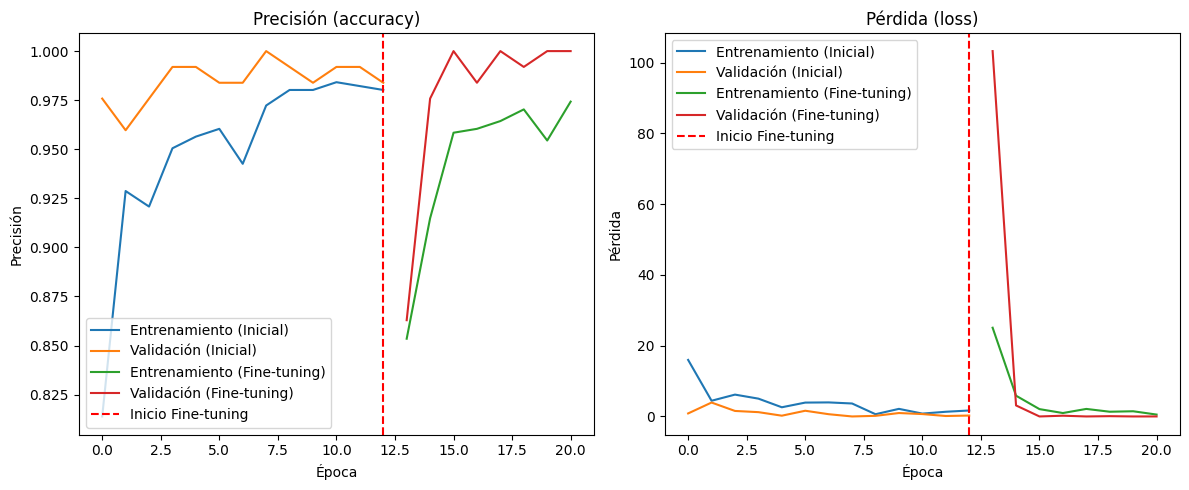

In [39]:
# Graficar curvas del fine tunning junto con las anteriores
# Graficar accuracy y loss de ambas fases, marcando el inicio del fine-tuning
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
# Fase inicial
plt.plot(history.history['accuracy'], label='Entrenamiento (Inicial)')
plt.plot(history.history['val_accuracy'], label='Validación (Inicial)')
# Fine-tuning
epochs_finetune = range(len(history.history['accuracy']), len(history.history['accuracy']) + len(history_fine_tune.history['accuracy']))
plt.plot(epochs_finetune, history_fine_tune.history['accuracy'], label='Entrenamiento (Fine-tuning)')
plt.plot(epochs_finetune, history_fine_tune.history['val_accuracy'], label='Validación (Fine-tuning)')
# Línea divisoria
plt.axvline(x=len(history.history['accuracy'])-1, color='red', linestyle='--', label='Inicio Fine-tuning')
plt.title('Precisión (accuracy)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento (Inicial)')
plt.plot(history.history['val_loss'], label='Validación (Inicial)')
plt.plot(epochs_finetune, history_fine_tune.history['loss'], label='Entrenamiento (Fine-tuning)')
plt.plot(epochs_finetune, history_fine_tune.history['val_loss'], label='Validación (Fine-tuning)')
plt.axvline(x=len(history.history['loss'])-1, color='red', linestyle='--', label='Inicio Fine-tuning')
plt.title('Pérdida (loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

Found 20 images belonging to 3 classes.
51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 373ms/step - accuracy: 0.9733 - loss: 1.2128
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 383ms/step - accuracy: 1.0000 - loss: 0.0000e+00


/home/don-berge/Documentos/IIA-TPS/TP-FINAL/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.8333 - loss: 7.6013


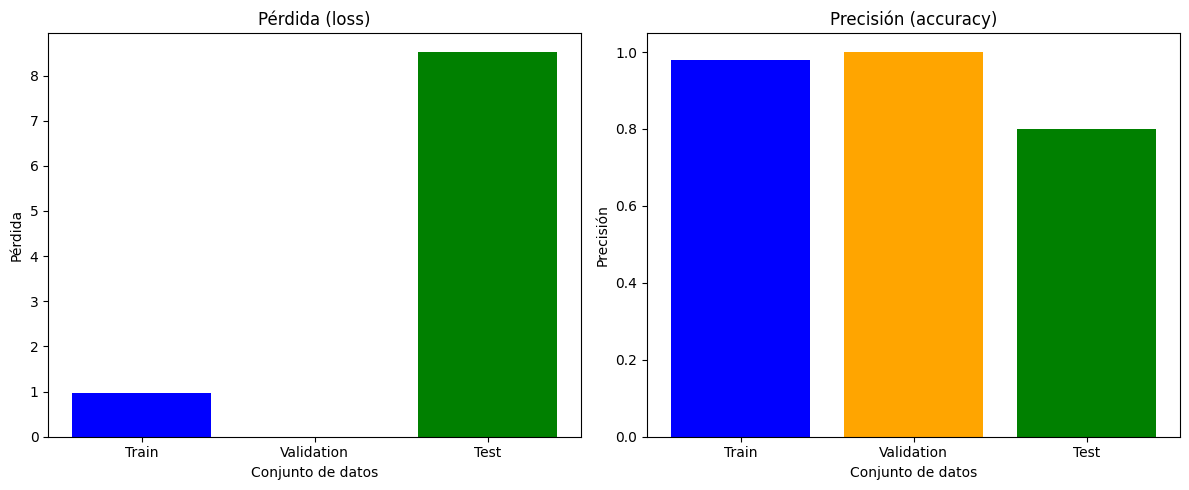

In [ ]:
test_dataset = test_dataset.flow_from_directory(
    'dataset/test',
    target_size=(150, 150),
    batch_size=10,
    classes=used_classes,
    class_mode='categorical',
)

# Evaluamos el modelo
train_loss, train_accuracy = model.evaluate(train_dataset)
validation_loss, validation_accuracy = model.evaluate(validation_dataset)
test_loss, test_accuracy = model.evaluate(test_dataset)

# Graficar el loss y accuracy de train, validacion y test
# en un histograma, donde cada columna tiene un color diferente
labels = ['Train', 'Validation', 'Test']
losses = [train_loss, validation_loss, test_loss]
accuracies = [train_accuracy, validation_accuracy, test_accuracy]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(labels, losses, color=['blue', 'orange', 'green'])
plt.title('Pérdida (loss)')
plt.xlabel('Conjunto de datos')
plt.ylabel('Pérdida')
plt.subplot(1, 2, 2)
plt.bar(labels, accuracies, color=['blue', 'orange', 'green'])
plt.title('Precisión (accuracy)')
plt.xlabel('Conjunto de datos')
plt.ylabel('Precisión')
plt.tight_layout()
plt.show()


Evaluamos sobre el conjunto de test

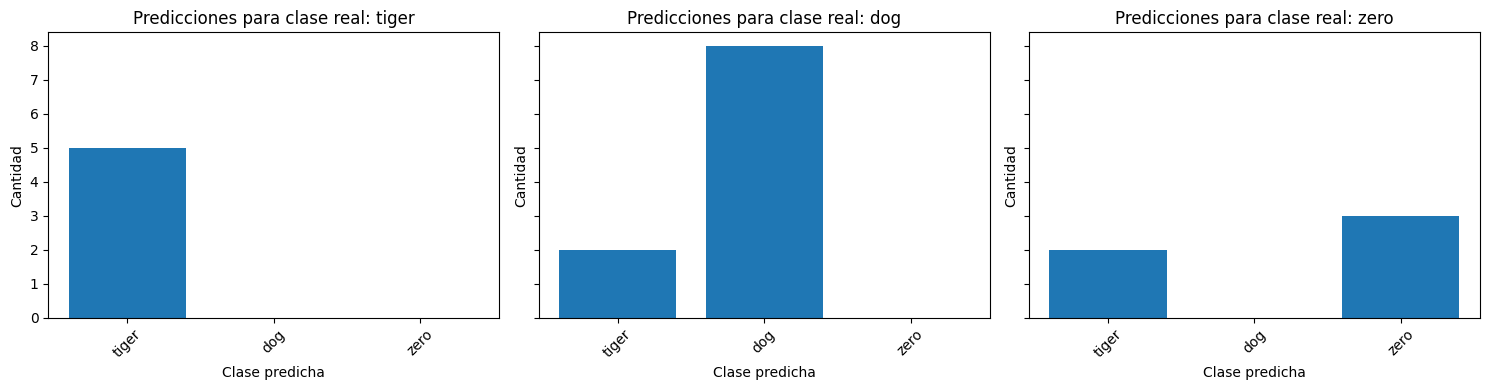

In [44]:
import numpy as np

dataset = test_dataset

# Obtener nombres de clases y número de clases
class_indices = dataset.class_indices
class_names = list(class_indices.keys())
num_classes = len(class_names)

# Obtener todas las imágenes y etiquetas verdaderas del test set
dataset.reset()
y_true = []
y_pred = []

for i in range(len(dataset)):
    x_batch, y_batch = dataset[i]
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Graficar histograma de predicciones para cada clase real
fig, axes = plt.subplots(1, num_classes, figsize=(5 * num_classes, 4), sharey=True)
if num_classes == 1:
    axes = [axes]

for idx, class_name in enumerate(class_names):
    mask = y_true == idx
    pred_for_class = y_pred[mask]
    axes[idx].hist(pred_for_class, bins=np.arange(num_classes+1)-0.5, rwidth=0.8, align='mid')
    axes[idx].set_xticks(range(num_classes))
    axes[idx].set_xticklabels(class_names, rotation=45)
    axes[idx].set_title(f'Predicciones para clase real: {class_name}')
    axes[idx].set_xlabel('Clase predicha')
    axes[idx].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

In [45]:
# Guardar el modelo
model.save('naruto_signs_{}.keras'.format(len(used_classes)))